## FD_abs[hhb2] ANN Fitting

In [ ]:
import sys
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/MCX_data'
sys.path.append(folder_path)

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os
import numpy as np
import sys
import pickle
from tqdm import tqdm
! pip install pmcx
from concurrent.futures import ThreadPoolExecutor
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 12.1 MB/s eta 0:00:00


### Read Simulation data

In [ ]:
# -*- coding: utf-8 -*-
# Train an ANN to predict HHB2 from MCX simulation pickles.

import os, re, pickle, math, random
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

### Add standard scaler.

### 2 branches model

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Lambda, Concatenate
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def build_FDnirsANN_model(input_dim=808,
                          optimizer=None,
                          loss='mse',
                          metrics=None,
                          lr=3e-4):
    """
    One-input (808x1) → Flatten → split into two 404-d vectors →
    two branches → concat → head → scalar.
    """
    if optimizer is None:
        optimizer = Adam(learning_rate=lr)
    if metrics is None:
        metrics = ['mae']

    # --- single 808x1 input (matches your X_*_v21 tensors) ---
    inp = Input(shape=(input_dim, 1), name="concat_808x1")  # e.g., (808,1)
    flat = Flatten(name="flatten_808")(inp)                 # -> (808,)

    # --- split into two 404-d vectors ---
    half = input_dim // 2                                   # 404
    x_a = Lambda(lambda t: t[:, :half],  name="x_a_404")(flat)
    x_b = Lambda(lambda t: t[:, half:], name="x_b_404")(flat)

    # --- branch definition (unshared; tweak sizes if you want) ---
    def branch(z, prefix):
        z = Dense(1024, activation='relu', name=f'{prefix}_d1')(z)
        z = Dropout(0.2, name=f'{prefix}_drop1')(z)
        z = Dense(512, activation='relu', name=f'{prefix}_d2')(z)
        z = Dropout(0.2, name=f'{prefix}_drop2')(z)
        z = Dense(256, activation='relu', name=f'{prefix}_d3')(z)
        z = Dropout(0.1, name=f'{prefix}_drop3')(z)
        return z

    a = branch(x_a, "branchA")
    b = branch(x_b, "branchB")

    # --- horizontal concat + head ---
    merged = Concatenate(name="concat_branches")([a, b])
    h = Dense(512, activation='relu', name='head_d1')(merged)
    h = Dropout(0.2, name='head_drop1')(h)
    h = Dense(128, activation='relu', name='head_d2')(h)
    h = Dropout(0.1, name='head_drop2')(h)
    out = Dense(1, activation='linear', name='y_hat')(h)

    model = Model(inputs=inp, outputs=out, name="FDnirs_808x1_split_2branch")
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model


Found 3500 simulations with GT.


Loading sims:   0%|          | 0/3500 [00:00<?, ?file/s]

Base split sizes → train: 2800, val: 350, test: 350
Pair sizes → train: 112000, val: 14000, test: 14000
Input concat vector shape (train): (112000, 808, 1)
y_train (scaled) shape: (112000,)
Epoch 1/200
1746/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9993 - mae: 0.8149
Epoch 1: val_mae improved from inf to 0.81980, saving model to best_pair_ann_808x1.h5


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 0.9993 - mae: 0.8149 - val_loss: 1.0040 - val_mae: 0.8198 - learning_rate: 3.0000e-04
Epoch 2/200
1733/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9043 - mae: 0.7752
Epoch 2: val_mae improved from 0.81980 to 0.78795, saving model to best_pair_ann_808x1.h5


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.9043 - mae: 0.7752 - val_loss: 0.9282 - val_mae: 0.7880 - learning_rate: 3.0000e-04
Epoch 3/200
1730/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8400 - mae: 0.7451
Epoch 3: val_mae improved from 0.78795 to 0.76852, saving model to best_pair_ann_808x1.h5


...

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5859 - mae: 0.6153 - val_loss: 0.7044 - val_mae: 0.6791 - learning_rate: 3.0000e-04
Epoch 10/200
1737/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5685 - mae: 0.6061
Epoch 10: val_mae did not improve from 0.67910
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5685 - mae: 0.6061 - val_loss: 0.7544 - val_mae: 0.6978 - learning_rate: 3.0000e-04
Epoch 11/200
1739/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5535 - mae: 0.5967
Epoch 11: val_mae improved from 0.67910 to 0.67877, saving model to best_pair_ann_808x1.h5


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5535 - mae: 0.5968 - val_loss: 0.7068 - val_mae: 0.6788 - learning_rate: 3.0000e-04
Epoch 12/200
1743/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5400 - mae: 0.5895
Epoch 12: val_mae did not improve from 0.67877
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5400 - mae: 0.5895 - val_loss: 0.7123 - val_mae: 0.6808 - learning_rate: 3.0000e-04
Epoch 13/200
1734/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5269 - mae: 0.5816
Epoch 13: val_mae did not improve from 0.67877
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5270 - mae: 0.5816 - val_loss: 0.7374 - val_mae: 0.6940 - learning_rate: 3.0000e-04
Epoch 14/200
1736/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5084 - mae: 0.5703
Epoch 14: val_mae did not improve from 0.67877
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5084 - mae: 0.5703 - val_loss: 0.7176 - val_mae: 0.6844 - learning_rate: 3.0000e-04
Epoch 15/200
1740/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3786 - mae: 0.4885 - val_loss: 0.6986 - val_mae: 0.6732 - learning_rate: 1.5000e-04
Epoch 23/200
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3547 - mae: 0.4710
Epoch 23: val_mae did not improve from 0.67315
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3547 - mae: 0.4710 - val_loss: 0.7090 - val_mae: 0.6780 - learning_rate: 1.5000e-04
Epoch 24/200
1730/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3436 - mae: 0.4633
Epoch 24: val_mae did not improve from 0.67315
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3435 - mae: 0.4632 - val_loss: 0.7482 - val_mae: 0.6949 - learning_rate: 1.5000e-04
Epoch 25/200
1744/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3378 - mae: 0.4585
Epoch 25: val_mae did not improve from 0.67315
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3377 - mae: 0.4585 - val_loss: 0.7142 - val_mae: 0.6807 - learning_rate: 1.5000e-04
Epoch 26/200
1730/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3170 - mae: 0.4439 - val_loss: 0.6791 - val_mae: 0.6632 - learning_rate: 1.5000e-04
Epoch 28/200
1734/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3112 - mae: 0.4394
Epoch 28: val_mae did not improve from 0.66320
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3112 - mae: 0.4394 - val_loss: 0.7161 - val_mae: 0.6787 - learning_rate: 1.5000e-04
Epoch 29/200
1736/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3032 - mae: 0.4330
Epoch 29: val_mae did not improve from 0.66320
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3032 - mae: 0.4330 - val_loss: 0.7304 - val_mae: 0.6870 - learning_rate: 1.5000e-04
Epoch 30/200
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2954 - mae: 0.4271
Epoch 30: val_mae did not improve from 0.66320
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2954 - mae: 0.4271 - val_loss: 0.7505 - val_mae: 0.6948 - learning_rate: 1.5000e-04
Epoch 31/200
1730/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


=== TEST METRICS on pairwise ΔHHB2 (concat 808×1; de-normalized) ===
MAE : 5.064549
RMSE: 6.365867
R^2 : 0.406678
Saved best model → best_pair_ann_808x1.h5


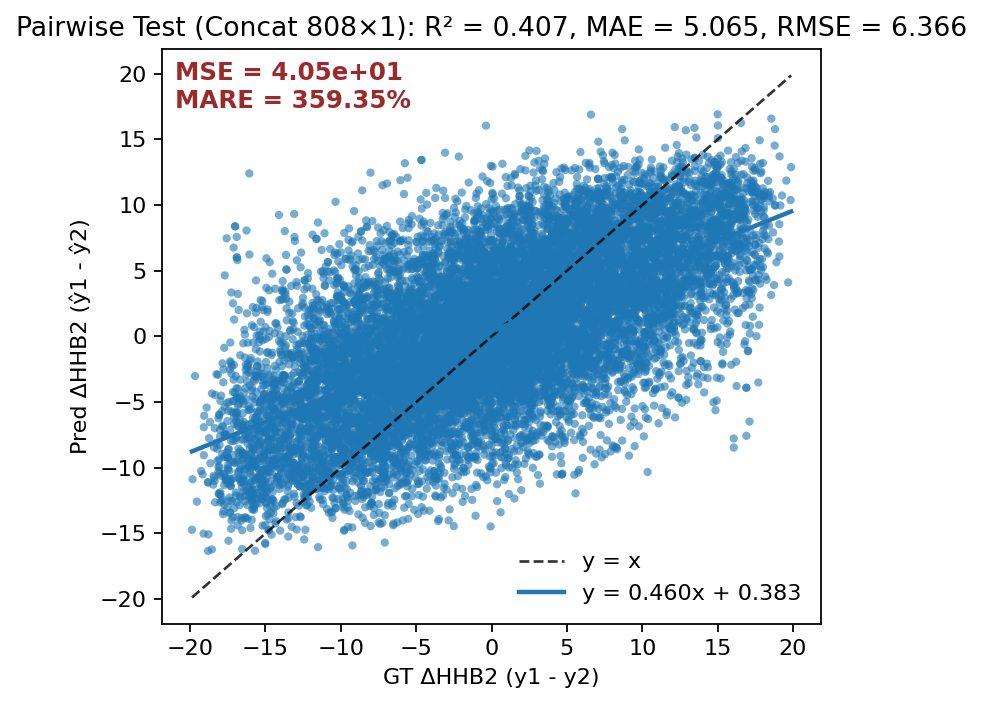

In [ ]:
from pathlib import Path
import os, math, random, pickle
from typing import Tuple, List

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler  # <-- added

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

# ---------------------
# Paths / Config
# ---------------------
RESULT_ROOT = Path('/content/drive/MyDrive/MCX_data/result_folder/cw_stage1')
GT_CSV      = Path('/content/drive/MyDrive/MCX_data/cw_stage1_csv/satge1.csv')

ID_COL      = 'ID'
TARGET_COL  = 'HHB2'

# Use 4 keys → 4 * 101 = 404 features per sample
KEYS_TO_USE: List[int] = [10, 20, 30, 40]
EACH_LEN    = 101
D_FEATURES  = len(KEYS_TO_USE) * EACH_LEN     # = 404
D_INPUT     = 2 * D_FEATURES                  # = 808  (concat x_i, x_j)

# Split ratios (80/10/10)
TEST_SIZE   = 0.10
VAL_SIZE    = 0.10
SEED        = 1337

# Pair construction
PAIRS_PER_ITEM = 20
INCLUDE_BOTH_DIRECTIONS = True  # also (j,i)

# Training
BATCH_SIZE  = 64
EPOCHS      = 200
LR          = 1e-4
BEST_MODEL  = 'best_pair_ann_808x1.h5'

# Loading perf
USE_THREADS = True
NUM_WORKERS = min(32, (os.cpu_count() or 8) * 2)

# ---------------------
# Repro & GPU mem growth
# ---------------------
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# ---------------------
# Helpers
# ---------------------
def _as_float1d(x, want_len):
    a = np.asarray(x, dtype=np.float32).ravel()
    if a.size == want_len:
        return a
    # if your pickles might have different lengths, replace with resample/interp
    raise ValueError(f"Feature length {a.size} != expected {want_len}")

def load_pickle_feature(pkl_path: Path, keys: List[int], each_len: int = EACH_LEN) -> np.ndarray:
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)

    def get_key(d, k):
        if k in d: return d[k]
        sk = str(k)
        if sk in d: return d[sk]
        raise KeyError(f"Missing key {k} (/'{sk}') in {pkl_path}")

    parts = []
    for k in keys:
        v = _as_float1d(get_key(obj, k), each_len)
        parts.append(v)
    feat = np.concatenate(parts, axis=0).astype(np.float32)
    if feat.size != D_FEATURES:
        raise ValueError(f"{pkl_path}: got {feat.size}, expected {D_FEATURES}")
    return feat

# ---------------------
# Read GT and build ID -> target mapping
# ---------------------
if not GT_CSV.exists():
    raise FileNotFoundError(f"GT CSV not found: {GT_CSV}")

gt_df = pd.read_csv(GT_CSV)
cols_lc = {c.lower(): c for c in gt_df.columns}
if ID_COL.lower() not in cols_lc or TARGET_COL.lower() not in cols_lc:
    raise ValueError(f"CSV must contain '{ID_COL}' and '{TARGET_COL}'. Found: {list(gt_df.columns)}")
ID_COL_REAL     = cols_lc[ID_COL.lower()]
TARGET_COL_REAL = cols_lc[TARGET_COL.lower()]

id_to_target = dict(zip(gt_df[ID_COL_REAL].astype(int).tolist(),
                        gt_df[TARGET_COL_REAL].astype(float).tolist()))

# ---------------------
# Scan folders and collect simulations (ID, path)
# ---------------------
if not RESULT_ROOT.exists():
    raise FileNotFoundError(f"RESULT_ROOT not found: {RESULT_ROOT}")

sim_list: List[Tuple[int, Path]] = []
for sub in sorted(RESULT_ROOT.glob('part*')):
    if not sub.is_dir():
        continue
    for p in sorted(sub.glob('*.pkl')):
        try:
            pid = int(Path(p).stem)
        except Exception:
            continue
        if pid in id_to_target:
            sim_list.append((pid, p))

if not sim_list:
    raise RuntimeError("No matching (ID, pickle) pairs found. Check folders/filenames.")

print(f"Found {len(sim_list)} simulations with GT.")

# ---------------------
# Load base dataset once (X_base, y_base, ids_base)
# ---------------------
N_base = len(sim_list)
X_base = np.empty((N_base, D_FEATURES), dtype=np.float32)
y_base = np.empty(N_base, dtype=np.float32)
ids_base = np.empty(N_base, dtype=np.int64)

def _load_one(i_and_pair):
    i, (pid, p) = i_and_pair
    feat = load_pickle_feature(p, KEYS_TO_USE, EACH_LEN)
    return i, pid, feat

if USE_THREADS:
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
        for i, pid, feat in tqdm(ex.map(_load_one, enumerate(sim_list)),
                                 total=N_base, desc="Loading sims", unit="file"):
            X_base[i] = feat
            y_base[i] = float(id_to_target[pid])
            ids_base[i] = int(pid)
else:
    for i, (pid, p) in tqdm(enumerate(sim_list), total=N_base, desc="Loading sims", unit="file"):
        feat = load_pickle_feature(p, KEYS_TO_USE, EACH_LEN)
        X_base[i] = feat
        y_base[i] = float(id_to_target[pid])
        ids_base[i] = int(pid)

# ---------------------
# Split base simulations → 80/10/10 (no leakage)
# ---------------------
X_trainval_base, X_test_base, y_trainval_base, y_test_base = train_test_split(
    X_base, y_base, test_size=TEST_SIZE, random_state=SEED
)
val_frac_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_trainval_base, y_trainval_base, test_size=val_frac_of_trainval, random_state=SEED
)

print(f"Base split sizes → train: {len(y_train_base)}, val: {len(y_val_base)}, test: {len(y_test_base)}")

# ---------------------
# Build pairs inside each split (CONCAT inputs, raw Δy target)
# ---------------------
rng = np.random.default_rng(SEED)

def make_pairs_concat(X: np.ndarray, y: np.ndarray,
                      pairs_per_item: int = PAIRS_PER_ITEM,
                      include_both: bool = INCLUDE_BOTH_DIRECTIONS,
                      rng: np.random.Generator = rng) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      Xc: [M, 2*D] where = concat(x_i, x_j)
      yp: [M] with yp = y_i - y_j
    """
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    N, D = X.shape
    if N < 2:
        raise ValueError("Need at least 2 samples to form pairs.")

    max_pairs = N * pairs_per_item * (2 if include_both else 1)
    Xc = np.empty((max_pairs, 2 * D), dtype=np.float32)
    yp = np.empty(max_pairs, dtype=np.float32)
    used = 0

    indices = np.arange(N)
    for i in range(N):
        cand = indices[indices != i]
        if cand.size == 0:
            continue
        partners = cand if pairs_per_item >= cand.size else rng.choice(cand, size=pairs_per_item, replace=False)

        for j in partners:
            # (x_i ; x_j)
            Xc[used, :D] = X[i]
            Xc[used, D:] = X[j]
            yp[used] = y[i] - y[j]
            used += 1

            if include_both:
                # (x_j ; x_i)
                Xc[used, :D] = X[j]
                Xc[used, D:] = X[i]
                yp[used] = y[j] - y[i]
                used += 1

    return Xc[:used], yp[:used]

X_train_concat, y_train_pairs = make_pairs_concat(X_train_base, y_train_base)
X_val_concat,   y_val_pairs   = make_pairs_concat(X_val_base,   y_val_base)
X_test_concat,  y_test_pairs  = make_pairs_concat(X_test_base,  y_test_base)

print(f"Pair sizes → train: {len(y_train_pairs)}, val: {len(y_val_pairs)}, test: {len(y_test_pairs)}")

# ---------------------
# STANDARDIZE AFTER PAIRING (fit on TRAIN only)
# ---------------------
scaler_X = StandardScaler()  # mean/std across features of the 808-dim vector
X_train_scaled = scaler_X.fit_transform(X_train_concat)
X_val_scaled   = scaler_X.transform(X_val_concat)
X_test_scaled  = scaler_X.transform(X_test_concat)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_pairs.reshape(-1, 1)).astype(np.float32).ravel()
y_val_scaled   = scaler_y.transform(y_val_pairs.reshape(-1, 1)).astype(np.float32).ravel()
# keep raw test target for metrics; model preds will be inverse-transformed later
y_test_raw     = y_test_pairs.astype(np.float32).reshape(-1)

# Build (808,1) inputs for the ANN
X_train_v21 = X_train_scaled.astype(np.float32)[..., None]   # (M, 808, 1)
X_val_v21   = X_val_scaled.astype(np.float32)[..., None]
X_test_v21  = X_test_scaled.astype(np.float32)[..., None]

print("Input concat vector shape (train):", X_train_v21.shape)
print("y_train (scaled) shape:", y_train_scaled.shape)

# ---------------------
# tf.data pipelines
# ---------------------
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_v21, y_train_scaled))
            .shuffle(8192, seed=SEED, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val_v21, y_val_scaled)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# ---------------------
# Train ANN (same model; just pass new input length)
# ---------------------
# >>> Your build_FDnirsANN_model must accept (input_len, lr, loss, etc.) and output a scalar <<<
model = build_FDnirsANN_model(D_INPUT, loss='mse')

callbacks = [
    keras.callbacks.ModelCheckpoint(BEST_MODEL, monitor='val_mae', mode='min',
                                    save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=10,
                                      min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_mae', mode='min',
                                  patience=20, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

# Ensure the best version is saved
model.save(BEST_MODEL)

# ---------------------
# Evaluate on TEST pairs
#  - Model outputs normalized Δy; invert to RAW units for metrics/plots
# ---------------------
best = keras.models.load_model(BEST_MODEL, compile=False)
pred_test_scaled = best.predict(X_test_v21, batch_size=BATCH_SIZE, verbose=0).ravel().astype(np.float64)
pred_test_raw = scaler_y.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()

mae  = mean_absolute_error(y_test_raw, pred_test_raw)
rmse = math.sqrt(mean_squared_error(y_test_raw, pred_test_raw))
r2   = r2_score(y_test_raw, pred_test_raw)

print("\n=== TEST METRICS on pairwise ΔHHB2 (concat 808×1; de-normalized) ===")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.6f}")
print(f"Saved best model → {BEST_MODEL}")

# ---------------------
# Plot GT ΔHHB2 vs Pred ΔHHB2 (RAW units)
# ---------------------
plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test_raw, pred_test_raw, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test_raw), np.min(pred_test_raw)))
hi = float(max(np.max(y_test_raw), np.max(pred_test_raw)))
if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
    lo, hi = -1.0, 1.0

plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

if np.std(y_test_raw) > 0:
    a, b = np.polyfit(y_test_raw, pred_test_raw, 1)
    xx = np.linspace(lo, hi, 200)
    plt.plot(xx, a * xx + b, lw=2, label=f'y = {a:.3f}x + {b:.3f}')

mse  = mean_squared_error(y_test_raw, pred_test_raw)
mare = np.mean(np.abs((pred_test_raw - y_test_raw) / np.clip(np.abs(y_test_raw), 1e-8, None))) * 100.0

plt.xlabel("GT ΔHHB2 (y1 - y2)")
plt.ylabel("Pred ΔHHB2 (ŷ1 - ŷ2)")
plt.title(f"Pairwise Test (Concat 808×1): R² = {r2:.3f}, MAE = {mae:.3f}, RMSE = {rmse:.3f}")

txt = f"MSE = {mse:.2e}\nMARE = {mare:.2f}%"
plt.text(0.02, 0.98, txt,
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()
